In [1]:
import os
from pathlib import Path
import torch, numpy as np, pandas as pd

In [2]:
np.set_printoptions(linewidth=140)
torch.set_printoptions(linewidth=140, sci_mode=False, edgeitems=7)
pd.set_option('display.width', 140)

In [3]:
df = pd.read_csv("train.csv")
df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1, inplace=True)

In [4]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [5]:
df.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [6]:
modes = df.mode().iloc[0]
modes

Survived       0
Pclass         3
Sex         male
Age         24.0
SibSp          0
Parch          0
Fare        8.05
Embarked       S
Name: 0, dtype: object

In [7]:
df.fillna(modes, inplace=True)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,24.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [8]:
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

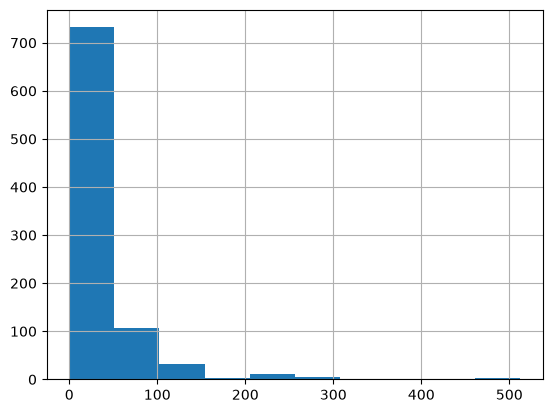

In [9]:
df["Fare"].hist();

In [10]:
df["logFare"]=np.log(df["Fare"]+1)

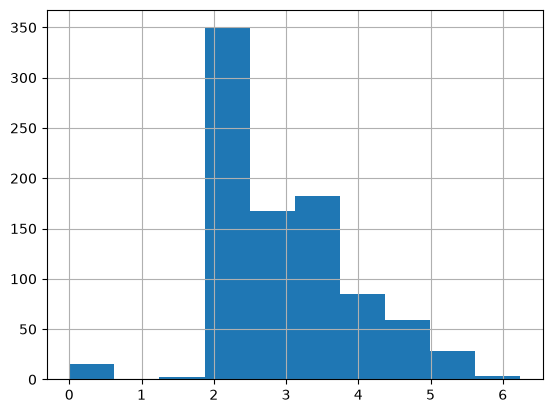

In [11]:
df["logFare"].hist();

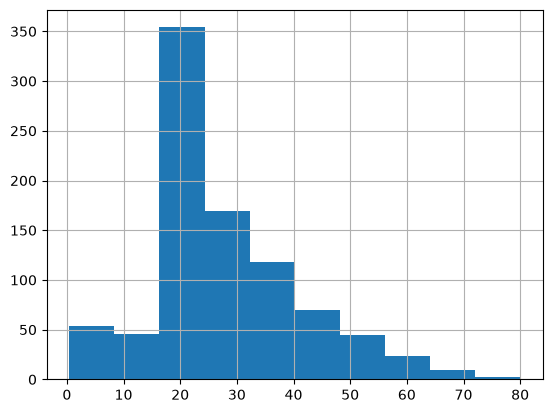

In [12]:
df["Age"].hist();

In [13]:
df = pd.get_dummies(df, columns=["Sex", "Pclass", "Embarked"]).astype(float)

In [14]:
df

,Survived,Age,SibSp,Parch,Fare,logFare,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S
0,0.0,22.0,1.0,0.0,7.2500,2.110213,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1.0,38.0,1.0,0.0,71.2833,4.280593,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1.0,26.0,0.0,0.0,7.9250,2.188856,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,1.0,35.0,1.0,0.0,53.1000,3.990834,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,35.0,0.0,0.0,8.0500,2.202765,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0.0,27.0,0.0,0.0,13.0000,2.639057,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
887,1.0,19.0,0.0,0.0,30.0000,3.433987,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
888,0.0,24.0,1.0,2.0,23.4500,3.196630,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
889,1.0,26.0,0.0,0.0,30.0000,3.433987,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [15]:
indep_columns = ["Survived", "Age", "SibSp", 'Parch', "logFare", "Sex_female", "Sex_male", "Pclass_1", "Pclass_2", "Pclass_3"]
dep_columns = ["Embarked_C", "Embarked_Q", "Embarked_S"]

In [16]:
from torch import tensor

In [17]:
t_indep = tensor(df[indep_columns].values, dtype=torch.float)
t_dep = tensor(df[dep_columns].values, dtype=torch.float)

t_indep.shape, t_dep.shape

(torch.Size([891, 10]), torch.Size([891, 3]))

In [18]:
t_indep

tensor([[ 0.0000, 22.0000,  1.0000,  0.0000,  2.1102,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [ 1.0000, 38.0000,  1.0000,  0.0000,  4.2806,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000],
        [ 1.0000, 26.0000,  0.0000,  0.0000,  2.1889,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000],
        [ 1.0000, 35.0000,  1.0000,  0.0000,  3.9908,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000],
        [ 0.0000, 35.0000,  0.0000,  0.0000,  2.2028,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [ 0.0000, 24.0000,  0.0000,  0.0000,  2.2469,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [ 0.0000, 54.0000,  0.0000,  0.0000,  3.9677,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000, 25.0000,  0.0000,  0.0000,  2.0857,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [ 0.0000, 39.0000,  0.0000,  5.0000,  3.4054,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000],
        [ 0.0000, 27.0000,  0.0000,  0.0000,  2.6391,  0.0000,  1.0000,  0.0000,  1.000

In [19]:
t_dep

tensor([[0., 0., 1.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 0., 1.],
        ...,
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 1., 0.]])

In [20]:
max_values, indices = t_indep.max(axis=0)
t_indep = t_indep/max_values

In [21]:
t_indep

tensor([[0.0000, 0.2750, 0.1250, 0.0000, 0.3381, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        [1.0000, 0.4750, 0.1250, 0.0000, 0.6859, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000],
        [1.0000, 0.3250, 0.0000, 0.0000, 0.3507, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [1.0000, 0.4375, 0.1250, 0.0000, 0.6395, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000],
        [0.0000, 0.4375, 0.0000, 0.0000, 0.3530, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.3000, 0.0000, 0.0000, 0.3600, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.6750, 0.0000, 0.0000, 0.6358, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.3125, 0.0000, 0.0000, 0.3342, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.4875, 0.0000, 0.8333, 0.5456, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.3375, 0.0000, 0.0000, 0.4229, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000],
        [1.0000, 0.2375, 0.0000, 0.0000, 0.5502, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000

In [22]:
n_coeff = t_indep.shape[1]
n_target = t_dep.shape[1]

In [23]:
n_coeff, n_target

(10, 3)

In [24]:
torch.manual_seed(442)
coeffs = (torch.rand(n_coeff, n_target)-0.5).requires_grad_()

In [25]:
result = t_indep@coeffs

In [26]:
result

tensor([[-0.1564,  0.5371, -0.4932],
        [-0.0790, -0.1199, -0.6150],
        [-0.7392,  0.3563, -0.4953],
        [-0.0785, -0.1208, -0.5866],
        [-0.2515,  0.4586, -0.5846],
        [-0.2192,  0.4964, -0.5439],
        [ 0.3189, -0.0921, -0.7482],
        ...,
        [-0.2265,  0.4871, -0.5386],
        [-0.6455,  0.3955, -0.5549],
        [ 0.3782,  0.2253, -0.0746],
        [-0.1096, -0.1281, -0.5267],
        [-0.3283,  0.3712, -0.6302],
        [-0.0795,  0.1188, -0.3665],
        [-0.2440,  0.4672, -0.5709]], grad_fn=<MmBackward0>)

In [27]:
result_exp_sum = torch.exp(result-result.max(axis=1, keepdim=True).values).sum(axis=1, keepdim=True)
result_softmax = torch.exp(result-result.max(axis=1, keepdim=True).values)/result_exp_sum
result_softmax

tensor([[0.2692, 0.5386, 0.1922],
        [0.3929, 0.3772, 0.2299],
        [0.1899, 0.5678, 0.2423],
        [0.3906, 0.3744, 0.2350],
        [0.2666, 0.5423, 0.1911],
        [0.2654, 0.5428, 0.1918],
        [0.4983, 0.3303, 0.1714],
        ...,
        [0.2650, 0.5410, 0.1940],
        [0.2030, 0.5748, 0.2222],
        [0.4010, 0.3441, 0.2549],
        [0.3787, 0.3718, 0.2495],
        [0.2665, 0.5364, 0.1971],
        [0.3367, 0.4106, 0.2527],
        [0.2661, 0.5419, 0.1919]], grad_fn=<DivBackward0>)

In [28]:
t_dep

tensor([[0., 0., 1.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 0., 1.],
        ...,
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 1., 0.]])

In [29]:
torch.log(result_softmax)

tensor([[-1.3123, -0.6188, -1.6491],
        [-0.9341, -0.9750, -1.4701],
        [-1.6615, -0.5659, -1.4176],
        [-0.9401, -0.9824, -1.4482],
        [-1.3220, -0.6119, -1.6551],
        [-1.3266, -0.6110, -1.6513],
        [-0.6966, -1.1076, -1.7637],
        ...,
        [-1.3279, -0.6143, -1.6401],
        [-1.5947, -0.5537, -1.5041],
        [-0.9139, -1.0668, -1.3667],
        [-0.9710, -0.9895, -1.3881],
        [-1.3223, -0.6228, -1.6242],
        [-1.0885, -0.8902, -1.3755],
        [-1.3238, -0.6126, -1.6507]], grad_fn=<LogBackward0>)

In [30]:
loss = -((((t_dep*torch.log(result_softmax)).sum(axis=1)).sum())/len(t_indep))
loss, len(t_indep)

(tensor(1.3651, grad_fn=<NegBackward0>), 891)

In [31]:
loss.backward()

In [32]:
with torch.no_grad():
    coeffs.sub_(coeffs.grad*0.1)
    coeffs.grad.zero_()

In [33]:
def calc_preds(coeffs, indep):
    result = indep@coeffs
    result_shifted = result - result.max(axis=1, keepdim=True).values
    result_exp = torch.exp(result_shifted)
    return result_exp / result_exp.sum(axis=1, keepdim=True)

In [34]:
def calc_loss(coeffs, indep, dep):
    return -((((dep*torch.log(calc_preds(coeffs, indep))).sum(axis=1)).sum())/len(indep))

In [35]:
def update_coeffs(coeffs, lr):
    coeffs.sub_(coeffs.grad*lr)
    coeffs.grad.zero_()

In [36]:
from fastai.data.transforms import RandomSplitter
trn_split, val_split = RandomSplitter(seed=42)(df)

In [37]:
trn_split

(#713) [np.int64(788),np.int64(525),np.int64(821),np.int64(253),np.int64(374),np.int64(98),np.int64(215),np.int64(313),np.int64(281),np.int64(305)...]

In [38]:
val_split

(#178) [np.int64(303),np.int64(778),np.int64(531),np.int64(385),np.int64(134),np.int64(476),np.int64(691),np.int64(443),np.int64(386),np.int64(128)...]

In [39]:
trn_indep, val_indep = t_indep[trn_split], t_indep[val_split]
trn_dep, val_dep = t_dep[trn_split], t_dep[val_split]

trn_indep.shape, val_indep.shape, trn_dep.shape, val_dep.shape

(torch.Size([713, 10]),
 torch.Size([178, 10]),
 torch.Size([713, 3]),
 torch.Size([178, 3]))

In [40]:
def init_coeffs():
    coeffs = (torch.rand(n_coeff, n_target)-0.5).requires_grad_()
    return coeffs

In [41]:
def one_epoch(coeffs, lr):
    training_loss = calc_loss(coeffs, trn_indep, trn_dep)
    training_loss.backward()
    with torch.no_grad(): update_coeffs(coeffs, lr)
    print(f"{training_loss:.3f}", end="; ")

In [42]:
def train_model(n_epoch=30, lr=0.1):
    torch.manual_seed(442)
    coeffs = init_coeffs()
    for i in range(n_epoch): one_epoch(coeffs, lr)
    return coeffs

In [43]:
coeffs = train_model(300,2)

1.370; 0.746; 0.727; 0.716; 0.707; 0.700; 0.695; 0.690; 0.686; 0.683; 0.680; 0.677; 0.675; 0.673; 0.671; 0.669; 0.668; 0.666; 0.665; 0.664; 0.663; 0.662; 0.661; 0.661; 0.660; 0.659; 0.659; 0.658; 0.658; 0.657; 0.657; 0.656; 0.656; 0.656; 0.655; 0.655; 0.655; 0.654; 0.654; 0.654; 0.654; 0.653; 0.653; 0.653; 0.653; 0.652; 0.652; 0.652; 0.652; 0.652; 0.651; 0.651; 0.651; 0.651; 0.651; 0.651; 0.650; 0.650; 0.650; 0.650; 0.650; 0.650; 0.649; 0.649; 0.649; 0.649; 0.649; 0.649; 0.649; 0.649; 0.648; 0.648; 0.648; 0.648; 0.648; 0.648; 0.648; 0.648; 0.648; 0.647; 0.647; 0.647; 0.647; 0.647; 0.647; 0.647; 0.647; 0.647; 0.647; 0.647; 0.646; 0.646; 0.646; 0.646; 0.646; 0.646; 0.646; 0.646; 0.646; 0.646; 0.646; 0.646; 0.645; 0.645; 0.645; 0.645; 0.645; 0.645; 0.645; 0.645; 0.645; 0.645; 0.645; 0.645; 0.645; 0.645; 0.645; 0.644; 0.644; 0.644; 0.644; 0.644; 0.644; 0.644; 0.644; 0.644; 0.644; 0.644; 0.644; 0.644; 0.644; 0.644; 0.644; 0.644; 0.643; 0.643; 0.643; 0.643; 0.643; 0.643; 0.643; 0.643; 0.643;

In [44]:
preds = calc_preds(coeffs, val_indep)

In [45]:
predicted_indices = torch.argmax(preds, axis=1)
predicted_indices

tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2,
        2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2])

In [46]:
actual_indices = torch.argmax(val_dep, axis=1)
actual_indices

tensor([1, 1, 0, 2, 2, 2, 0, 2, 2, 0, 2, 0, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 0, 2, 2, 2, 2, 2, 0,
        2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 0, 0, 2,
        0, 2, 2, 2, 0, 0, 0, 0, 2, 1, 1, 1, 2, 1, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 1, 2, 0, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 0, 2, 2, 2, 0, 2, 2, 0, 2, 1, 2, 2, 2, 0, 2, 0, 2, 1, 2, 1, 1, 2, 2, 2, 2, 2, 0, 0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2])

In [47]:
accuracy = (predicted_indices==actual_indices).float().mean()
accuracy

tensor(0.7416)

In [48]:
def acc(coeffs): return ((torch.argmax(calc_preds(coeffs, val_indep), axis=1)==torch.argmax(val_dep, axis=1)).float().mean())
acc(coeffs)

tensor(0.7416)

In [49]:
def init_coeffs(n_hidden=10):
    layer1 = ((torch.rand(n_coeff, n_hidden)-0.5)/n_hidden).requires_grad_()
    layer2 = (torch.rand(n_hidden, n_target)-0.3).requires_grad_()
    const1 = (torch.rand(n_hidden)-0.5).requires_grad_()
    const2 = (torch.rand(n_target)-0.5).requires_grad_()
    return layer1, layer2, const1, const2

In [50]:
import torch.nn.functional as F

def calc_preds(coeffs, indep):
    l1, l2, c1, c2 = coeffs
    result = F.relu(indep@l1+c1)
    result = result@l2+c2

    result_shifted = result - result.max(axis=1, keepdim=True).values
    result_exp = torch.exp(result_shifted)
    return result_exp / result_exp.sum(axis=1, keepdim=True)

In [51]:
def update_coeffs(coeffs, lr):
    for layer in coeffs:
        layer.sub_(layer.grad*lr)
        layer.grad.zero_()

In [123]:
coeffs = train_model(2000,1.5)

1.105; 0.833; 0.776; 0.761; 0.756; 0.753; 0.752; 0.751; 0.750; 0.750; 0.749; 0.749; 0.749; 0.749; 0.749; 0.749; 0.749; 0.749; 0.749; 0.749; 0.749; 0.749; 0.749; 0.749; 0.749; 0.749; 0.749; 0.749; 0.749; 0.748; 0.748; 0.748; 0.748; 0.748; 0.748; 0.748; 0.748; 0.748; 0.748; 0.748; 0.747; 0.747; 0.747; 0.747; 0.747; 0.746; 0.746; 0.746; 0.745; 0.745; 0.745; 0.744; 0.743; 0.742; 0.741; 0.740; 0.739; 0.737; 0.735; 0.733; 0.730; 0.727; 0.724; 0.721; 0.719; 0.716; 0.714; 0.712; 0.710; 0.708; 0.707; 0.706; 0.705; 0.704; 0.704; 0.703; 0.702; 0.702; 0.701; 0.701; 0.700; 0.699; 0.699; 0.698; 0.698; 0.697; 0.697; 0.696; 0.696; 0.695; 0.695; 0.694; 0.694; 0.693; 0.692; 0.692; 0.691; 0.691; 0.690; 0.691; 0.690; 0.690; 0.689; 0.690; 0.688; 0.689; 0.688; 0.687; 0.687; 0.685; 0.686; 0.685; 0.686; 0.683; 0.684; 0.682; 0.685; 0.682; 0.682; 0.683; 0.686; 0.682; 0.683; 0.683; 0.689; 0.682; 0.684; 0.685; 0.695; 0.683; 0.685; 0.685; 0.696; 0.682; 0.685; 0.685; 0.695; 0.682; 0.688; 0.684; 0.695; 0.682; 0.690;

In [124]:
acc(coeffs)

tensor(0.7247)

In [130]:
def init_coeffs():
    hidden = [10, 10]
    sizes = [n_coeff] + hidden + [n_target]
    n = len(sizes)
    layers = [((torch.rand(sizes[i], sizes[i+1])-0.3)/sizes[i+1]).requires_grad_() for i in range(n-1)]
    consts = [((torch.rand(sizes[i+1])-0.5)*0.1).requires_grad_() for i in range(n-1)]
    return layers, consts

In [131]:
def calc_preds(coeffs, indep):
    layers, consts = coeffs
    n = len(layers)
    result = indep
    for i, layer in enumerate(layers):
        result = result@layer + consts[i]
        if(i!=n-1): result = F.relu(result)
            
    result_shifted = result - result.max(axis=1, keepdim=True).values
    result_exp = torch.exp(result_shifted)
    return result_exp / result_exp.sum(axis=1, keepdim=True)

In [132]:
def update_coeffs(coeffs, lr):
    layers, consts = coeffs
    for layer in layers+consts:
        layer.sub_(layer.grad*lr)
        layer.grad.zero_()

In [143]:
coeffs = train_model(5000,0.1)

1.105; 1.080; 1.057; 1.035; 1.015; 0.997; 0.980; 0.964; 0.949; 0.936; 0.923; 0.912; 0.901; 0.891; 0.882; 0.873; 0.865; 0.858; 0.851; 0.845; 0.839; 0.833; 0.828; 0.823; 0.819; 0.815; 0.811; 0.807; 0.804; 0.801; 0.798; 0.795; 0.793; 0.791; 0.788; 0.786; 0.784; 0.782; 0.781; 0.779; 0.778; 0.776; 0.775; 0.774; 0.773; 0.771; 0.770; 0.769; 0.768; 0.768; 0.767; 0.766; 0.765; 0.765; 0.764; 0.763; 0.763; 0.762; 0.762; 0.761; 0.761; 0.760; 0.760; 0.759; 0.759; 0.758; 0.758; 0.758; 0.757; 0.757; 0.757; 0.757; 0.756; 0.756; 0.756; 0.756; 0.755; 0.755; 0.755; 0.755; 0.754; 0.754; 0.754; 0.754; 0.754; 0.754; 0.753; 0.753; 0.753; 0.753; 0.753; 0.753; 0.753; 0.752; 0.752; 0.752; 0.752; 0.752; 0.752; 0.752; 0.752; 0.752; 0.751; 0.751; 0.751; 0.751; 0.751; 0.751; 0.751; 0.751; 0.751; 0.751; 0.751; 0.751; 0.751; 0.751; 0.750; 0.750; 0.750; 0.750; 0.750; 0.750; 0.750; 0.750; 0.750; 0.750; 0.750; 0.750; 0.750; 0.750; 0.750; 0.750; 0.750; 0.750; 0.750; 0.750; 0.749; 0.749; 0.749; 0.749; 0.749; 0.749; 0.749;

In [144]:
acc(coeffs)

tensor(0.7360)